In [1]:
import pandas as pd
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# 1. Initialize a fresh SQLite database
db_path = '../data/omop_clinical.db'
conn = sqlite3.connect(db_path)
print("SQL Database Engine initialized!")

# 2. Ingest the core tables
print("Ingesting Person table...")
person_df = pd.read_csv('../data/person.csv')
person_df.to_sql('person', conn, if_exists='replace', index=False)

print("Ingesting Condition Occurrence table...")
condition_df = pd.read_csv('../data/condition_occurrence.csv')
condition_df.to_sql('condition_occurrence', conn, if_exists='replace', index=False)

# 3. Ingest our NEW Procedure table instead of the empty Drug table
print("Ingesting Procedure Occurrence table...")
procedure_df = pd.read_csv('../data/procedure_occurrence.csv')
procedure_df.to_sql('procedure_occurrence', conn, if_exists='replace', index=False)

print("\n✅ Success! New database built with Person, Condition, and Procedure tables.")

# 4. Quick sanity check to prove we have data
print(f"Total Procedures loaded: {len(procedure_df)}")

SQL Database Engine initialized!
Ingesting Person table...
Ingesting Condition Occurrence table...
Ingesting Procedure Occurrence table...

✅ Success! New database built with Person, Condition, and Procedure tables.
Total Procedures loaded: 1708698


In [3]:
# 1. The OPTIMIZED OMOP SQL Query
# We put the date math directly into the SQL JOIN to prevent memory explosion
omop_query = """
SELECT 
    p.person_id,
    (2024 - p.year_of_birth) AS approximate_age,
    p.gender_concept_id,
    co.condition_concept_id,
    co.condition_start_date,
    po.procedure_concept_id,
    po.procedure_date
FROM person p
JOIN condition_occurrence co 
    ON p.person_id = co.person_id
JOIN procedure_occurrence po 
    ON p.person_id = po.person_id
    -- THE MAGIC LINE: We force SQL to only match procedures that happened on/after the diagnosis
    AND po.procedure_date >= co.condition_start_date
-- Limit to the first 50,000 to keep our notebook lightning fast
LIMIT 50000;
"""

print("Executing Optimized OMOP Cohort Extraction Query...")
cohort_df = pd.read_sql_query(omop_query, conn)

print(f"✅ Success! Extracted {len(cohort_df)} valid clinical pathways in seconds.")

# Display the final, clean cohort!
display(cohort_df.head())

Executing Optimized OMOP Cohort Extraction Query...
✅ Success! Extracted 50000 valid clinical pathways in seconds.


,person_id,approximate_age,gender_concept_id,condition_concept_id,condition_start_date,procedure_concept_id,procedure_date
0,1,19,8532,28060,2014-05-21,762506,2019-08-07
1,1,19,8532,28060,2014-05-21,762506,2021-08-18
2,1,19,8532,28060,2014-05-21,762506,2023-08-30
3,1,19,8532,28060,2014-05-21,762506,2024-09-04
4,1,19,8532,28060,2014-05-21,4015701,2023-02-01


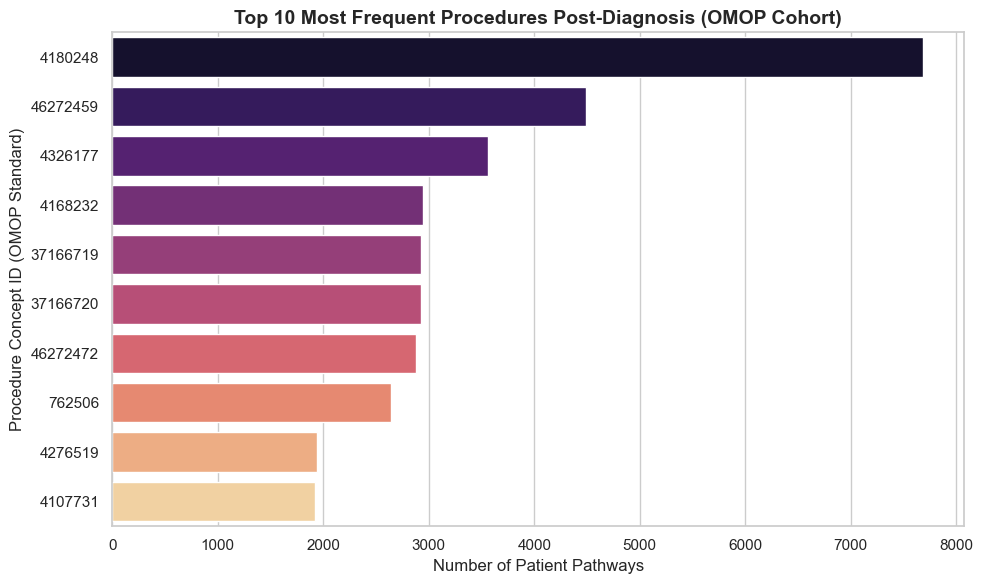


Analysis Complete! We have successfully extracted and visualized a clinical cohort.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for a professional look
sns.set_theme(style="whitegrid")

# Count the occurrences of each procedure in our valid cohort
top_procedures = cohort_df['procedure_concept_id'].value_counts().head(10)

# Create the Bar Chart
plt.figure(figsize=(10, 6))
# We convert the IDs to strings so they plot nicely as categories
sns.barplot(x=top_procedures.values, y=top_procedures.index.astype(str), palette='magma')

plt.title('Top 10 Most Frequent Procedures Post-Diagnosis (OMOP Cohort)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Patient Pathways', fontsize=12)
plt.ylabel('Procedure Concept ID (OMOP Standard)', fontsize=12)
plt.tight_layout()
plt.show()

print("\nAnalysis Complete! We have successfully extracted and visualized a clinical cohort.")

📊 Insight: The median time from diagnosis to procedure within the first year is 65.0 days.


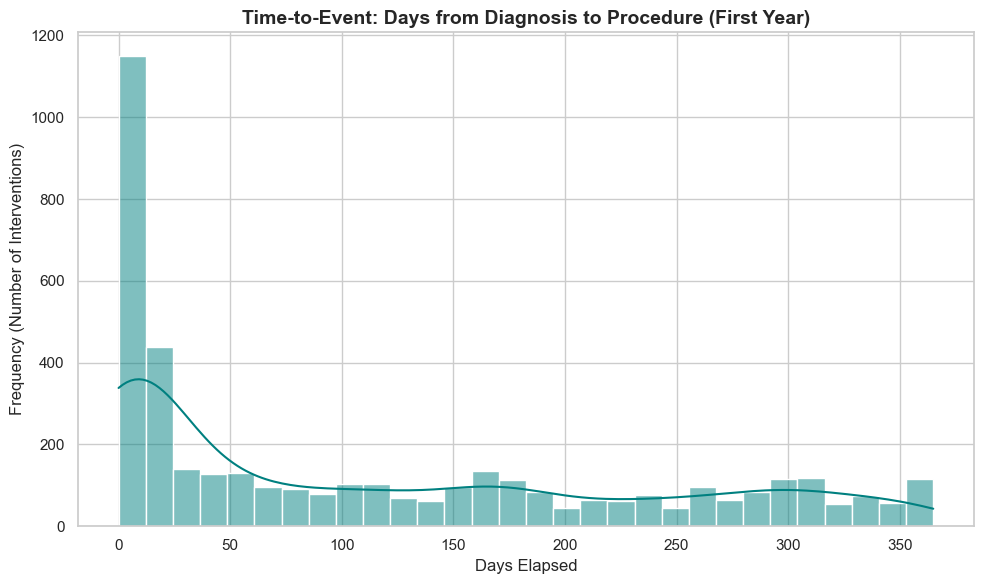

In [5]:
# 1. Convert the raw SQLite date strings into Pandas Datetime objects so we can do math
cohort_df['condition_start_date'] = pd.to_datetime(cohort_df['condition_start_date'])
cohort_df['procedure_date'] = pd.to_datetime(cohort_df['procedure_date'])

# 2. Calculate the "Time-to-Event" (Days between diagnosis and procedure)
cohort_df['days_to_procedure'] = (cohort_df['procedure_date'] - cohort_df['condition_start_date']).dt.days

# 3. Filter the data to focus on the immediate clinical response (e.g., within the first year)
# This removes noise from routine checkups that happen 10 years later
first_year_cohort = cohort_df[cohort_df['days_to_procedure'] <= 365]

median_days = first_year_cohort['days_to_procedure'].median()
print(f"📊 Insight: The median time from diagnosis to procedure within the first year is {median_days} days.")

# 4. Visualize the Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=first_year_cohort, x='days_to_procedure', bins=30, kde=True, color='teal')

plt.title('Time-to-Event: Days from Diagnosis to Procedure (First Year)', fontsize=14, fontweight='bold')
plt.xlabel('Days Elapsed', fontsize=12)
plt.ylabel('Frequency (Number of Interventions)', fontsize=12)
plt.tight_layout()
plt.show()